In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sparrow as sp
import spatialdata as sd
import spatialdata_io
import spatialdata_plot
import matplotlib.pyplot as plt


the value of the environment variable BASIC_DCT_BACKEND is not in ["JAX","SCIPY"]
2024-11-27 13:50:16,396 - sparrow.image.pixel_clustering._clustering - WARNING - 'flowsom' not installed, 'sp.im.flowsom' will not be available.
2024-11-27 13:50:16,429 - sparrow.table.cell_clustering._clustering - WARNING - 'flowsom' not installed, 'sp.tb.flowsom' will not be available.
2024-11-27 13:50:16,449 - sparrow.plot - WARNING - 'joypy' not installed, 'sp.pl.ridgeplot_channel' and 'sp.pl.ridgeplot_channel_sample' will not be available.
2024-11-27 13:50:16,450 - sparrow.plot - WARNING - 'textalloc' not installed, 'sp.pl.group_snr_ratio' and 'sp.pl.snr_ratio' will not be available.


In [6]:
sdata = spatialdata_io.visium_hd('../data/Visium_HD_MouseBrain_FF/',
                                 fullres_image_file="microscope_image/Visium_HD_Mouse_Brain_Fresh_Frozen_tissue_image.tif")
                                 #annotate_table_by_labels=True)
                                 
for table in sdata.tables.values():
    table.var_names_make_unique()


/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [7]:
sdata

SpatialData object
├── Images
│     ├── 'Visium_HD_Mouse_Brain_Fresh_Frozen_full_image': DataTree[cyx] (3, 23041, 32888), (3, 11520, 16444), (3, 5760, 8222), (3, 2880, 4111), (3, 1440, 2055)
│     ├── 'Visium_HD_Mouse_Brain_Fresh_Frozen_hires_image': DataArray[cyx] (3, 4204, 6000)
│     └── 'Visium_HD_Mouse_Brain_Fresh_Frozen_lowres_image': DataArray[cyx] (3, 421, 600)
├── Labels
│     ├── 'Visium_HD_Mouse_Brain_Fresh_Frozen_square_002um_labels': DataArray[yx] (3350, 3350)
│     ├── 'Visium_HD_Mouse_Brain_Fresh_Frozen_square_008um_labels': DataArray[yx] (838, 838)
│     └── 'Visium_HD_Mouse_Brain_Fresh_Frozen_square_016um_labels': DataArray[yx] (419, 419)
├── Shapes
│     ├── 'Visium_HD_Mouse_Brain_Fresh_Frozen_square_002um': GeoDataFrame shape: (7238362, 1) (2D shapes)
│     ├── 'Visium_HD_Mouse_Brain_Fresh_Frozen_square_008um': GeoDataFrame shape: (453820, 1) (2D shapes)
│     └── 'Visium_HD_Mouse_Brain_Fresh_Frozen_square_016um': GeoDataFrame shape: (113885, 1) (2D shapes)
└── Table

Load in the segmentation mask generated in 4_3

In [26]:
import geopandas as gpd
gdf = gpd.read_file( "../data/Visium_HD_MouseBrain_FF/segmentation_mask.geojson" )
gdf.index=gdf.index +1

### 1. Generate number of nuclei per 8um bin

/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/geopandas/geodataframe.py:2675: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: None

  return geopandas.overlay(
/tmp/ipykernel_90792/768816509.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  intersections["nucleus_area"] = intersections.geometry.area  # Calculate intersection area


<Axes: >

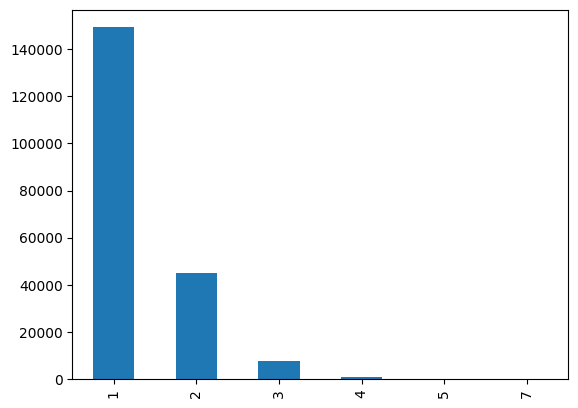

In [27]:
# Get grid shapes from sdata, and add grid_id to the grid shapes
grid_df = sdata.shapes['Visium_HD_Mouse_Brain_Fresh_Frozen_square_008um']
grid_df['grid_id'] = grid_df.index

# Create intersection between grid and nuclei
intersections = gdf.overlay(grid_df, how='intersection')
intersections["nucleus_area"] = intersections.geometry.area  # Calculate intersection area

# Calculate percentage of nucleus area over total grid area
grid_area = grid_df.geometry.area.values[0] # 853
intersections["nucleus_area_percentage"] = intersections["nucleus_area"] / grid_area

# What is the number of nuclei in each grid?
# Plot barplot of intersections.grid_id.value_counts()
nuclei_per_grid = intersections.grid_id.value_counts()
nuclei_per_grid = nuclei_per_grid.groupby(nuclei_per_grid.values).count()
nuclei_per_grid.plot(kind="bar")

/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


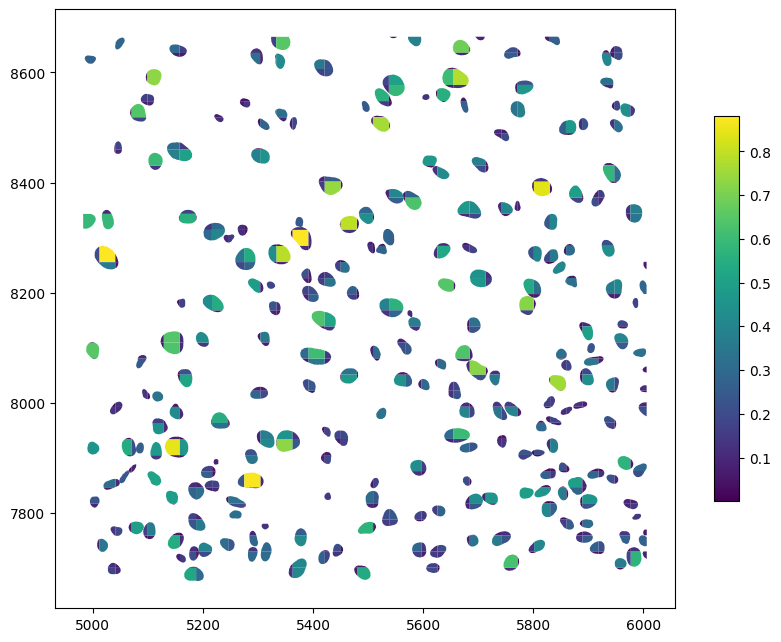

In [11]:
# Let's visualize this on a subset
# Only get intersections that are within the bounding box
bbox=(5000,6000, 7700,8664)

intersections_sub = intersections.cx[bbox[0]:bbox[1], bbox[2]:bbox[3]]
intersections_sub.set_crs("EPSG:4326", inplace=True, allow_override=True) # need to set this or it won't work

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
# Color different colors based on the percentage of nucleus area
intersections_sub.plot(column="nucleus_area_percentage", cmap="viridis", legend=False,ax=ax)

# Make legend smaller
cbar = ax.get_legend()
fig.colorbar(ax.collections[0], ax=ax, shrink=0.5, aspect=15)  # Adjust the colorbar with shrink and aspect


In [28]:
# Let's calculate some metrics
import scanpy as sc
sc.pp.calculate_qc_metrics(sdata.tables['square_008um'], inplace=True)

In [29]:
obs_008um_df = sdata.tables['square_008um'].obs
obs_008um_df["spot_id"] = sdata.tables['square_008um'].obs.index

# Combine this with the intersections, to get some statistics per bin
intersections_count = intersections.merge(obs_008um_df, left_on='grid_id', right_on='location_id')

# Remove geometry table, then save to csv
intersections_count = intersections_count.drop(columns='geometry')
intersections_count.to_csv('intersections.csv', index=False)

This is continued in 6_2, to more easily visualize it in ggplot

### 2. Plotting with sparrow

In [17]:
# Add segmentation boundaries to sdata
sdata=sp.sh.add_shapes_layer(
    sdata,
    input=gdf,
    output_layer="segmentation_boundaries",
    overwrite=True,
)

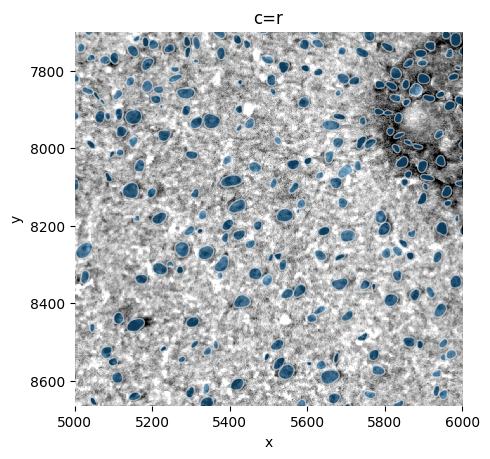

In [19]:
# Let's visualize 
bbox=(5000,6000,7700,8664)

sp.pl.plot_shapes(
    sdata, 
    img_layer="Visium_HD_Mouse_Brain_Fresh_Frozen_full_image",
    shapes_layer="segmentation_boundaries",
    crd=bbox,
    figsize=(5,5) ,
    channel="r",
      )

In [21]:
# Add segmentation boundaries as labels
labels_layer = "segmentation_mask"
sdata=sp.im.rasterize( sdata, shapes_layer="segmentation_boundaries", output_layer=labels_layer, overwrite=True )

2024-11-27 14:05:34,276 - sparrow.image._manager - WARNING - No dims parameter specified. Assuming order of dimension of provided array is ((c), (z), y, x)
2024-11-27 14:05:46,437 - sparrow.image._manager - INFO - Writing results to layer 'segmentation_mask'


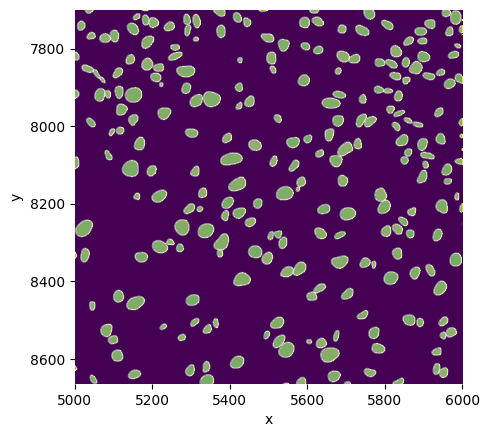

In [22]:
# sanity plot
sp.pl.plot_shapes(
    sdata, 
    labels_layer="segmentation_mask",
    shapes_layer="segmentation_boundaries",
    crd =bbox,
    figsize=(5,5),
    channel="r",
      )

In [23]:
# bin barcodes to the segmentation masks
sdata=sp.tb.bin_counts( 
    sdata,
    table_layer="square_008um",
    labels_layer="segmentation_mask",
    output_layer="table_custom_segmentation_008um",
    append = False,
    overwrite=True,
      )

2024-11-27 14:05:49,349 - sparrow.table._allocation - INFO - Calculating cell counts.
2024-11-27 14:05:49,964 - sparrow.table._allocation - INFO - 
 Number of spots per bin  Frequency
                       1      41215
                       2       1581
                       3         16
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


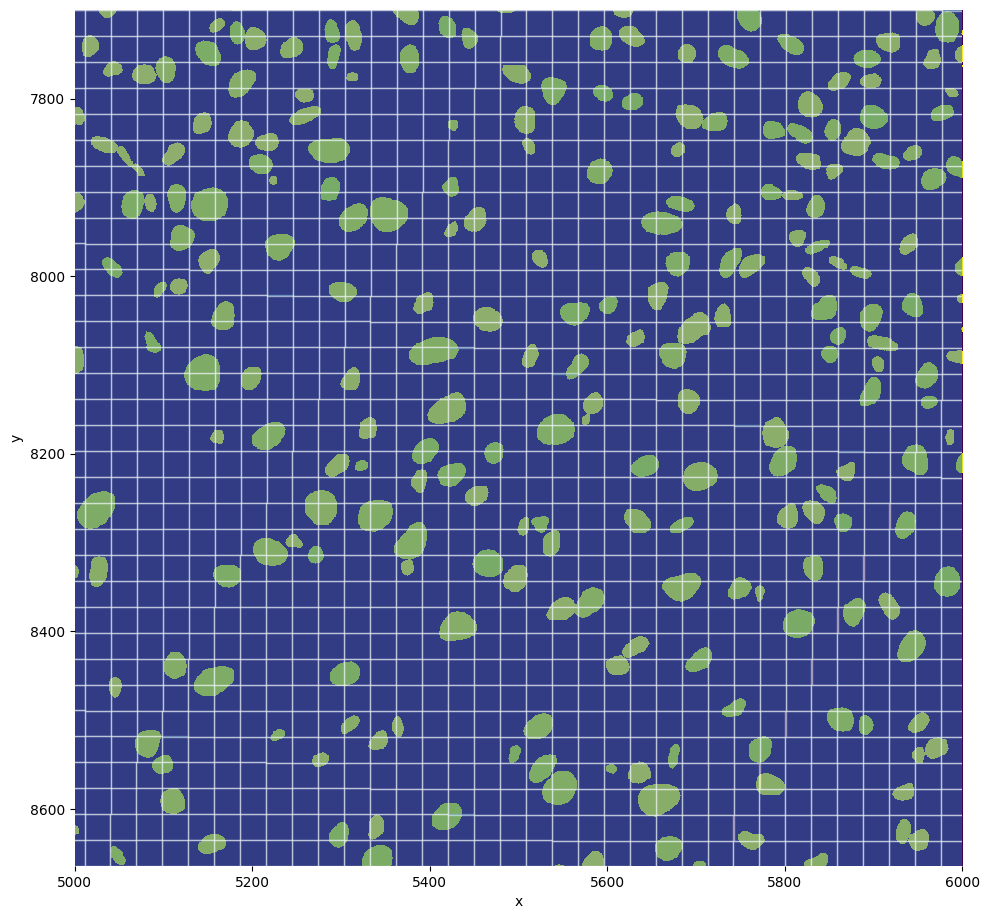

In [ ]:
# Visualizing both the grid and segmentation mask
sp.pl.plot_shapes(sdata,
                  shapes_layer= "Visium_HD_Mouse_Brain_Fresh_Frozen_square_008um",
                  labels_layer="segmentation_mask",
                  #img_layer="Visium_HD_Mouse_Brain_full_image",
                  to_coordinate_system="global",
                  crd =bbox,
                  channel="r",
                  figsize=(10,10),
                  linewidth=1,
                  table_layer="square_008um")

